# Bluestock MF Capstone — Day 3: Exploratory Data Analysis

This notebook contains the exploratory data analysis (EDA) for the Bluestock Mutual Fund Analytics Capstone. It loads 10 processed datasets, generates 15 publication-quality charts with detailed annotations, and documents key insights.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Style configuration
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# Paths
ROOT = Path('..')
PROCESSED = ROOT / 'data' / 'processed'
CHARTS = ROOT / 'reports' / 'charts'
CHARTS.mkdir(parents=True, exist_ok=True)

SUBTITLE = 'Source: AMFI India · mfapi.in · Bluestock Fintech Capstone 2026'

In [2]:
df_master  = pd.read_csv(PROCESSED / 'clean_fund_master.csv')
df_nav     = pd.read_csv(PROCESSED / 'clean_nav.csv', parse_dates=['date'])
df_aum     = pd.read_csv(PROCESSED / 'clean_aum_by_fund_house.csv', parse_dates=['date'])
df_sip     = pd.read_csv(PROCESSED / 'clean_sip_inflows.csv')
df_cat     = pd.read_csv(PROCESSED / 'clean_category_inflows.csv')
df_folio   = pd.read_csv(PROCESSED / 'clean_folio_count.csv')
df_perf    = pd.read_csv(PROCESSED / 'clean_performance.csv')
df_tx      = pd.read_csv(PROCESSED / 'clean_transactions.csv', parse_dates=['transaction_date'])
df_port    = pd.read_csv(PROCESSED / 'clean_portfolio_holdings.csv')
df_bench   = pd.read_csv(PROCESSED / 'clean_benchmark_indices.csv', parse_dates=['date'])

# Merge nav with master for readable labels
df_nav = df_nav.merge(df_master[['amfi_code','scheme_name','sub_category','fund_house']], on='amfi_code', how='left')
print('All datasets loaded.')

All datasets loaded.


## Chart 01 — NAV Trend Lines: All 40 Funds (2022–2026)

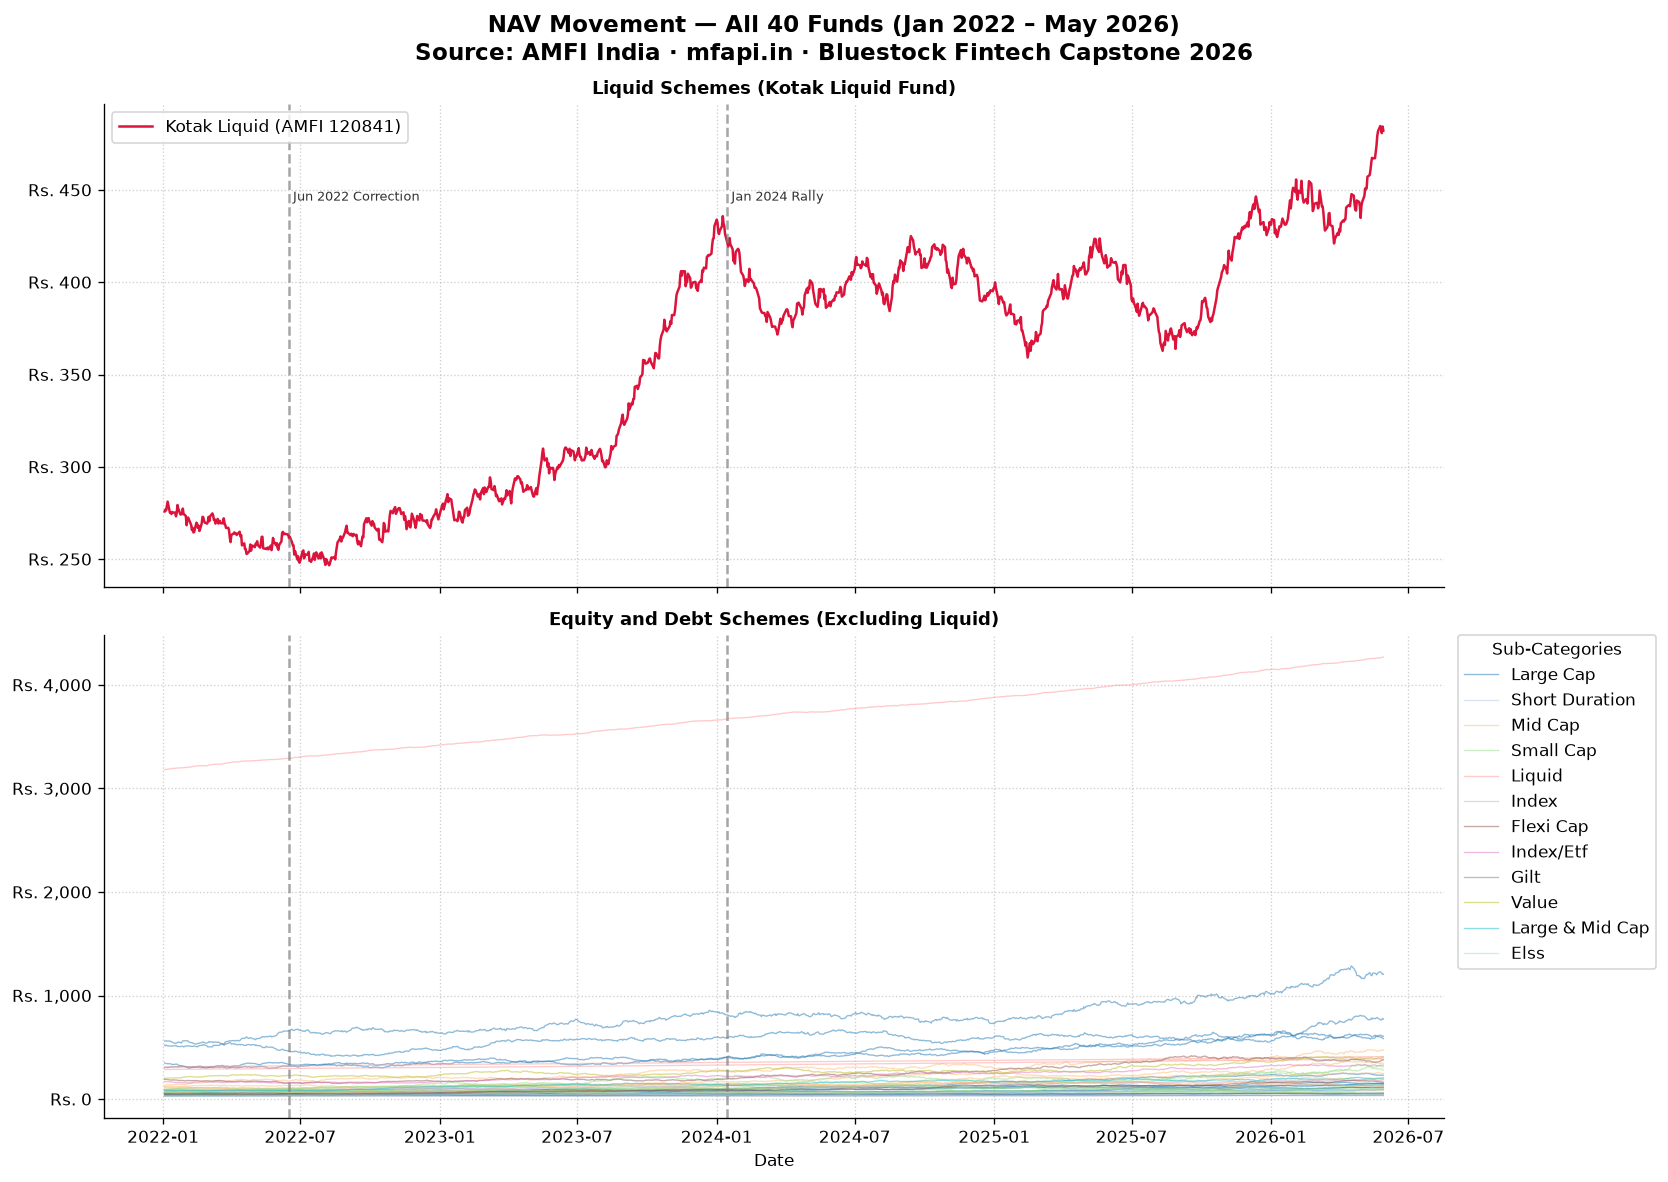

Chart 1 saved.


In [3]:
# --- Chart 1: NAV Trends ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Kotak Liquid (highest NAV)
df_liquid = df_nav[df_nav['amfi_code'] == 120841]
ax1.plot(df_liquid['date'], df_liquid['nav'], label='Kotak Liquid (AMFI 120841)', color='crimson', linewidth=1.5)
ax1.set_title('Liquid Schemes (Kotak Liquid Fund)', fontsize=11, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'Rs. {x:,.0f}'))
ax1.legend(loc='upper left')
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Other 39 schemes
df_others = df_nav[df_nav['amfi_code'] != 120841]
subcats = df_others['sub_category'].dropna().unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(subcats)))
color_map = dict(zip(subcats, colors))

for subcat in subcats:
    df_sub = df_others[df_others['sub_category'] == subcat]
    for amfi in df_sub['amfi_code'].unique():
        df_fund = df_sub[df_sub['amfi_code'] == amfi]
        label = subcat if amfi == df_sub['amfi_code'].unique()[0] else ''
        ax2.plot(df_fund['date'], df_fund['nav'], color=color_map[subcat], alpha=0.5, linewidth=0.8, label=label)

ax2.set_title('Equity and Debt Schemes (Excluding Liquid)', fontsize=11, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'Rs. {x:,.0f}'))
ax2.legend(loc='upper left', title='Sub-Categories', bbox_to_anchor=(1.01, 1), borderaxespad=0)
ax2.grid(True, linestyle=':', alpha=0.6)

for ax in [ax1, ax2]:
    for date_str, label in [('2022-06-16', 'Jun 2022 Correction'), ('2024-01-15', 'Jan 2024 Rally')]:
        ts = pd.to_datetime(date_str)
        ax.axvline(ts, color='gray', linestyle='--', alpha=0.7)
        if ax == ax1:
            ax.text(ts, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.8, f' {label}', fontsize=8, alpha=0.8)

plt.suptitle('NAV Movement — All 40 Funds (Jan 2022 – May 2026)\n' + SUBTITLE, fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_01_nav_trends_all_funds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

## Chart 02 — AUM Growth by Fund House (Grouped Bar)

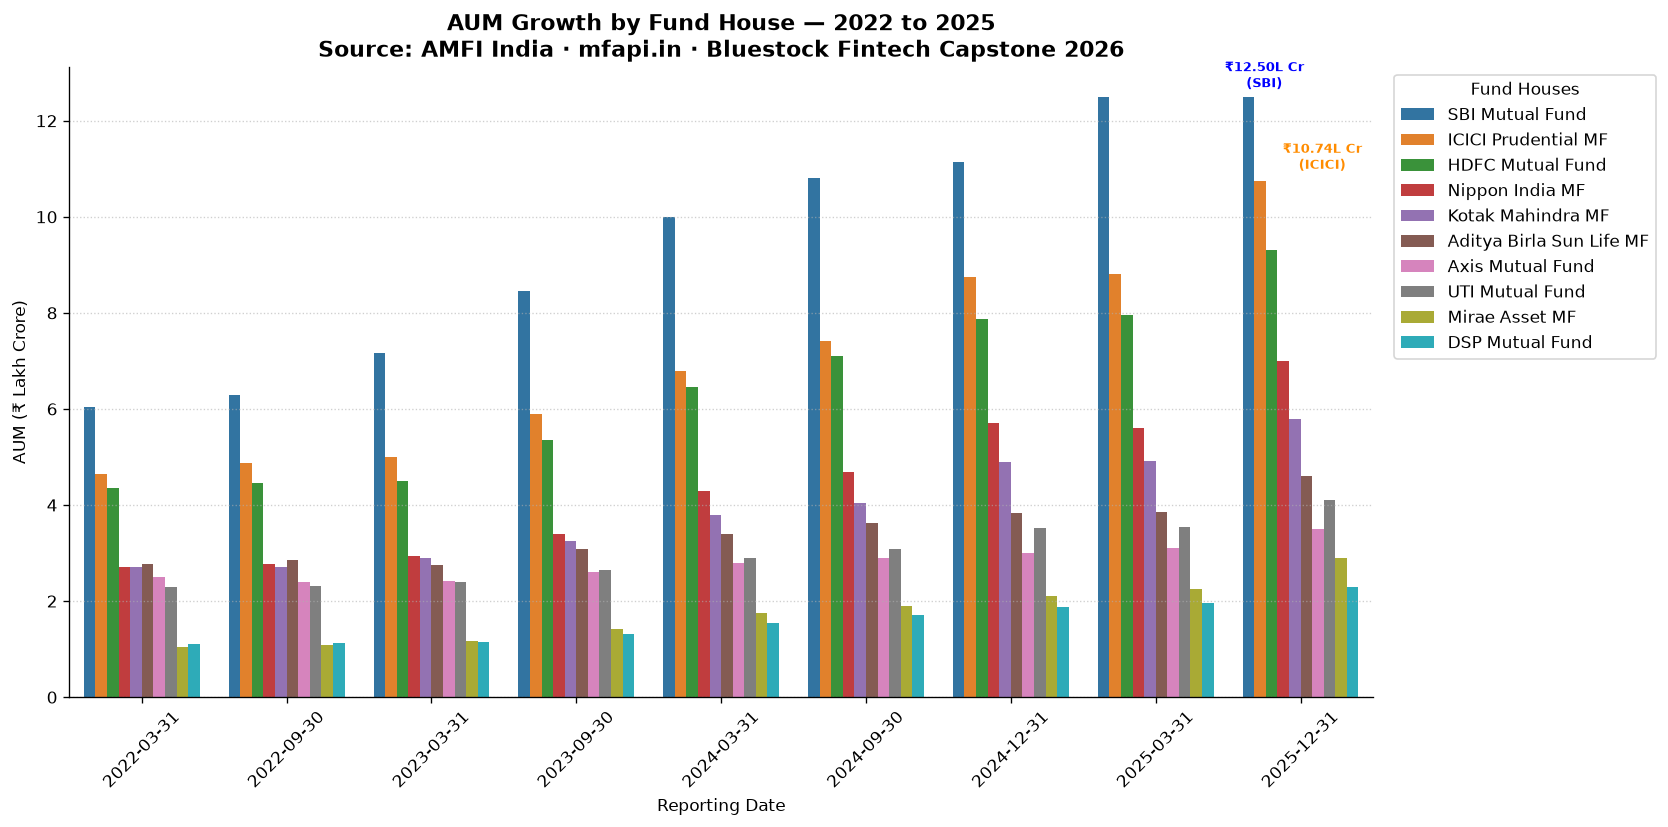

Chart 2 saved.


In [4]:
# --- Chart 2: AUM Growth ---
df_aum_plot = df_aum.copy()
df_aum_plot['Date String'] = df_aum_plot['date'].dt.strftime('%Y-%m-%d')
df_aum_plot = df_aum_plot.sort_values('date')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_aum_plot, x='Date String', y='aum_lakh_crore', hue='fund_house')
plt.title('AUM Growth by Fund House — 2022 to 2025\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel('Reporting Date')
plt.ylabel('AUM (₹ Lakh Crore)')
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)

unique_dates = df_aum_plot['Date String'].unique()
dec_2025_idx = list(unique_dates).index('2025-12-31')
plt.text(dec_2025_idx - 0.25, 12.7, '₹12.50L Cr\n(SBI)', ha='center', fontsize=8, color='blue', fontweight='bold')
plt.text(dec_2025_idx + 0.15, 11.0, '₹10.74L Cr\n(ICICI)', ha='center', fontsize=8, color='darkorange', fontweight='bold')

plt.legend(title='Fund Houses', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_02_aum_growth_by_amc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

## Chart 03 — SIP Inflow Time-Series with Milestone Annotation

In [5]:
# --- Chart 3: SIP Inflow Trend ---
df_sip_plot = df_sip.copy()
df_sip_plot['parsed_month'] = pd.to_datetime(df_sip_plot['month'] + '-01')
df_sip_plot = df_sip_plot.sort_values('parsed_month')

x_dates = df_sip_plot['parsed_month'].dt.strftime('%Y-%m-%d').tolist()
min_date = df_sip_plot['parsed_month'].min().strftime('%Y-%m-%d')
max_date = df_sip_plot['parsed_month'].max().strftime('%Y-%m-%d')

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=x_dates,
    y=df_sip_plot['sip_inflow_crore'],
    mode='lines+markers',
    name='SIP Inflow',
    line=dict(color='royalblue', width=2.5),
    fill='tozeroy',
    fillcolor='rgba(31,119,180,0.12)'
))

fig.add_shape(type='line', x0=min_date, x1=max_date, y0=31002, y1=31002, line=dict(color='Red', width=1.5, dash='dash'))
fig.add_shape(type='line', x0=min_date, x1=max_date, y0=11517, y1=11517, line=dict(color='Gray', width=1.5, dash='dash'))

fig.add_annotation(x=df_sip_plot['parsed_month'].iloc[-2].strftime('%Y-%m-%d'), y=31002, text='ATH: ₹31,002 Cr (Dec 2025)', showarrow=True, arrowhead=1, ax=10, ay=-25, font=dict(color='red'))
fig.add_annotation(x=df_sip_plot['parsed_month'].iloc[2].strftime('%Y-%m-%d'), y=11517, text='Start: ₹11,517 Cr (Jan 2022)', showarrow=True, arrowhead=1, ax=10, ay=25, font=dict(color='gray'))

fig.update_layout(
    title=dict(text=f'Monthly SIP Inflows — Jan 2022 to Dec 2025<br><sub>{SUBTITLE}</sub>', font=dict(size=16, family='DejaVu Sans')),
    xaxis_title='Month', yaxis_title='SIP Inflow (₹ Crore)', template='plotly_white', width=1000, height=500
)
fig.write_image(str(CHARTS / 'chart_03_sip_inflow_trend.png'))
fig.show()
print('Chart 3 saved.')

Chart 3 saved.


## Chart 04 — Category-Wise Inflow Heatmap

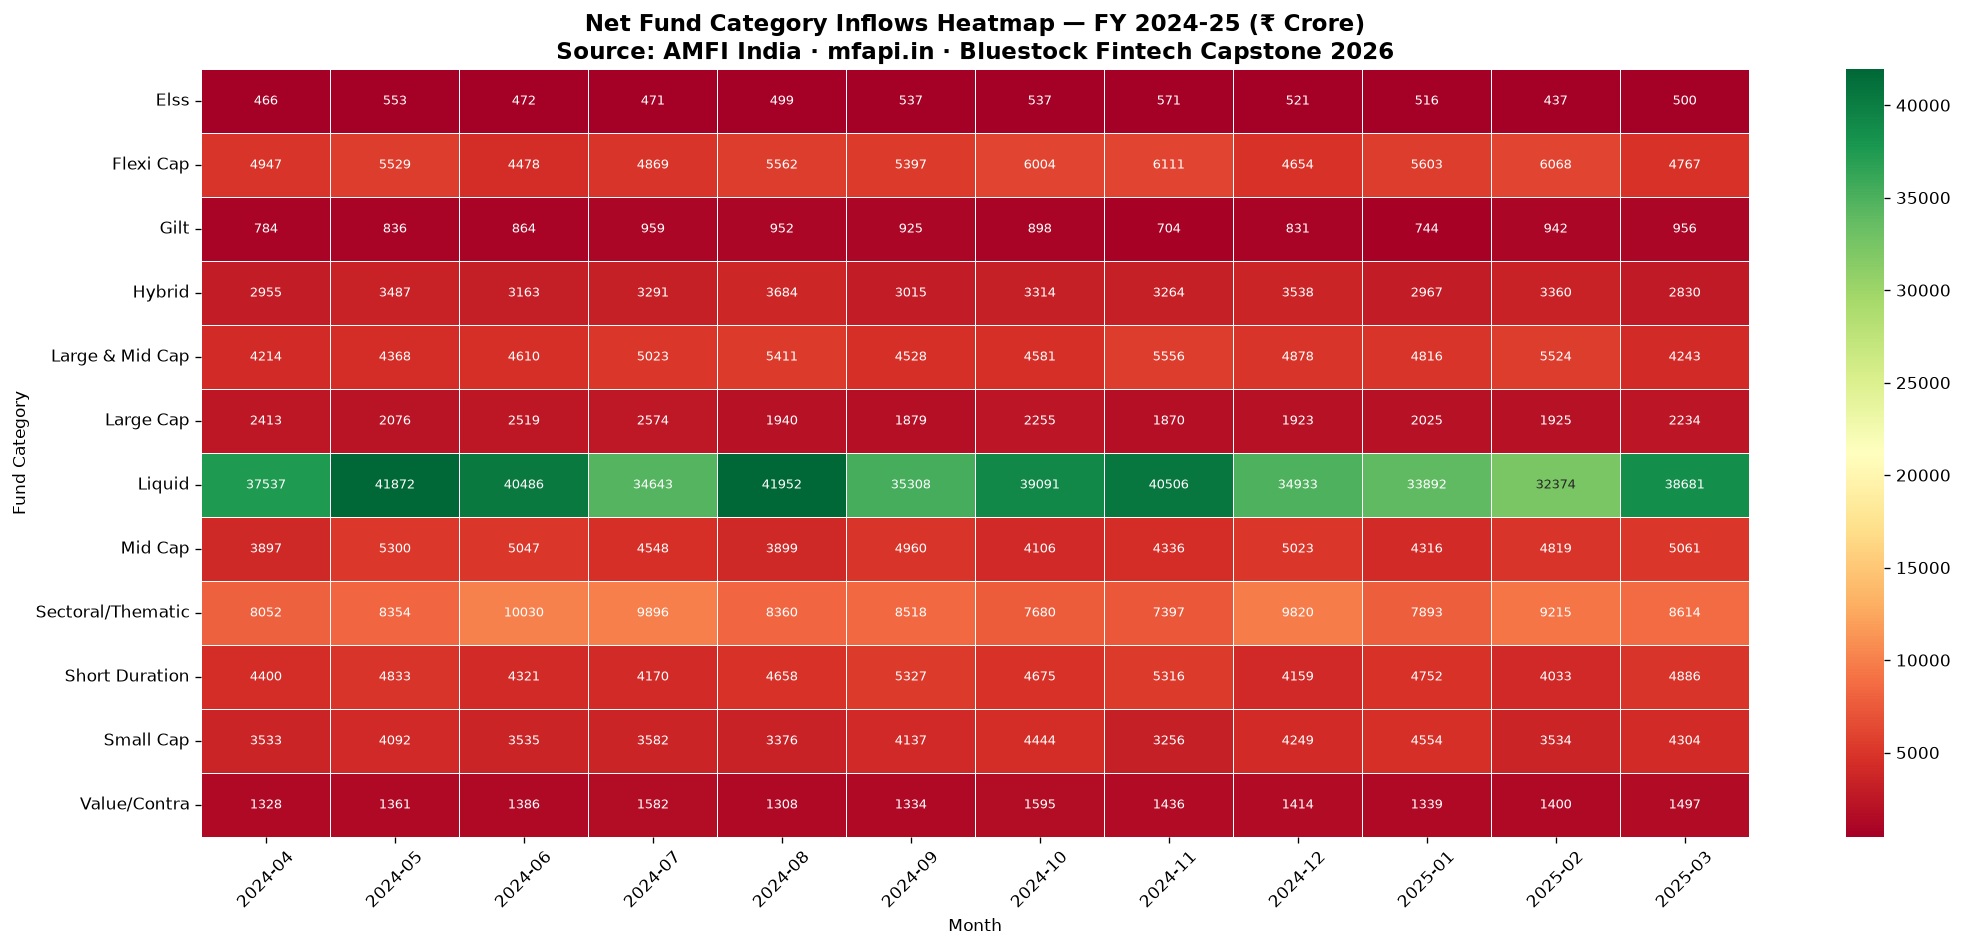

Chart 4 saved.


In [6]:
# --- Chart 4: Category Heatmap ---
df_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')
plt.figure(figsize=(18, 8))
sns.heatmap(df_pivot, cmap='RdYlGn', annot=True, fmt='.0f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Net Fund Category Inflows Heatmap — FY 2024-25 (₹ Crore)\n' + SUBTITLE, fontsize=14, fontweight='bold')
plt.ylabel('Fund Category')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHARTS / 'chart_04_category_inflow_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

## Chart 05 — Investor Age Group Distribution (Pie + Box)

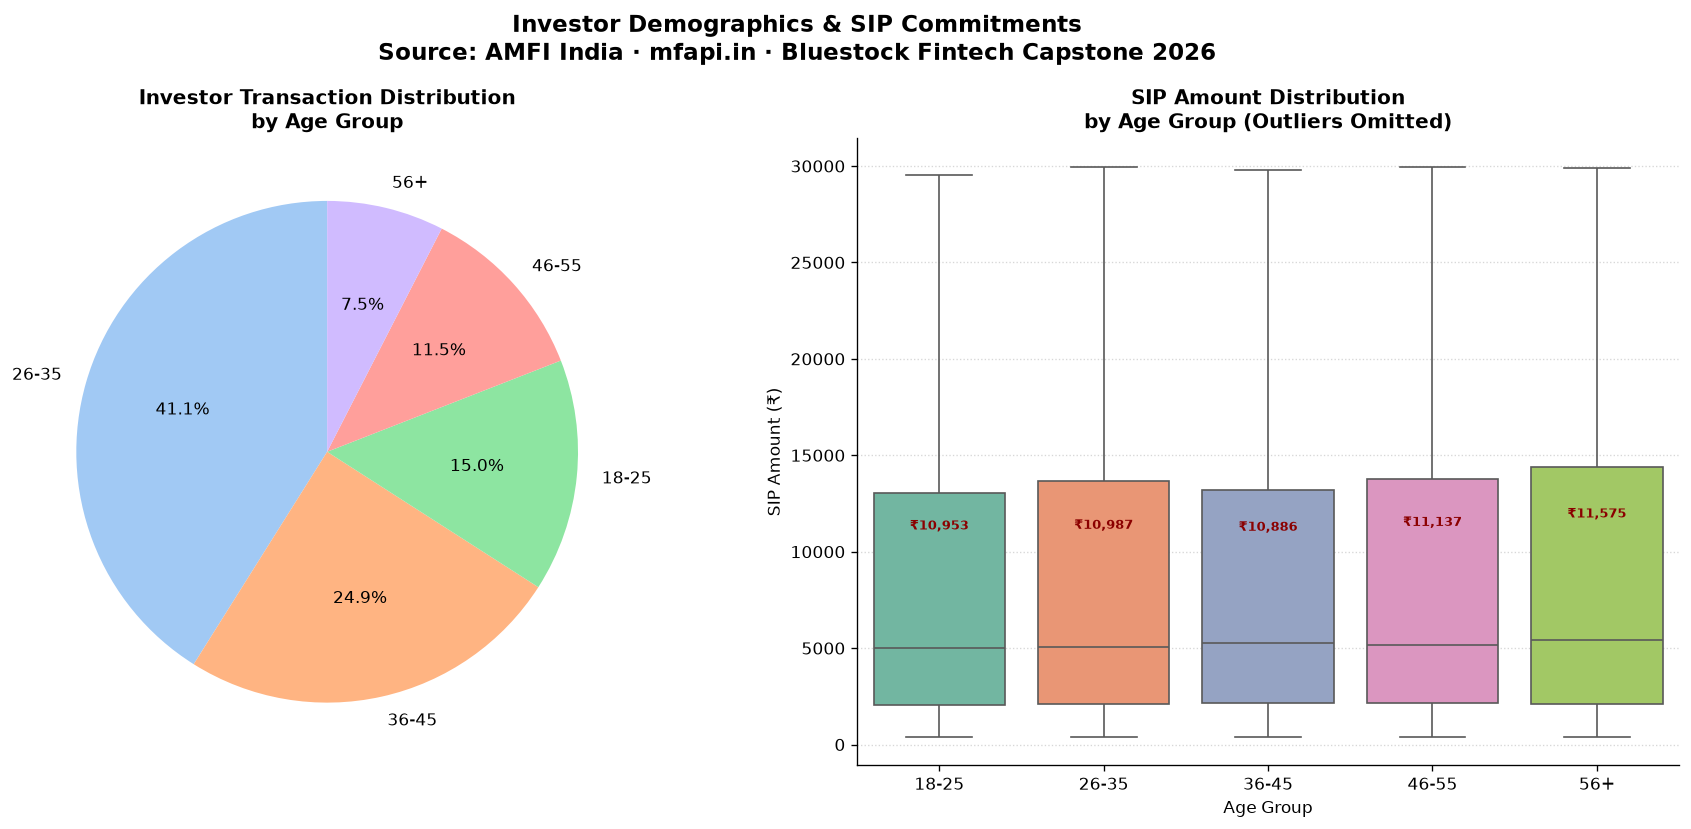

Chart 5 saved.


In [7]:
# --- Chart 5: Investor Demographics ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
age_counts = df_tx['age_group'].value_counts()
ax1.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax1.set_title('Investor Transaction Distribution\nby Age Group', fontsize=12, fontweight='bold')

df_sip_only = df_tx[df_tx['transaction_type'] == 'SIP']
sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', order=['18-25', '26-35', '36-45', '46-55', '56+'], showfliers=False, ax=ax2, palette='Set2')
ax2.set_title('SIP Amount Distribution\nby Age Group (Outliers Omitted)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('SIP Amount (₹)')
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

means = df_sip_only.groupby('age_group')['amount_inr'].mean()
order_ages = ['18-25', '26-35', '36-45', '46-55', '56+']
for i, age in enumerate(order_ages):
    val = means.get(age, 0)
    ax2.text(i, val + 200, f'₹{val:,.0f}', ha='center', fontsize=8, color='darkred', fontweight='bold')

plt.suptitle('Investor Demographics & SIP Commitments\n' + SUBTITLE, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_05_investor_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

## Chart 06 — Geographic Distribution of SIP Investments

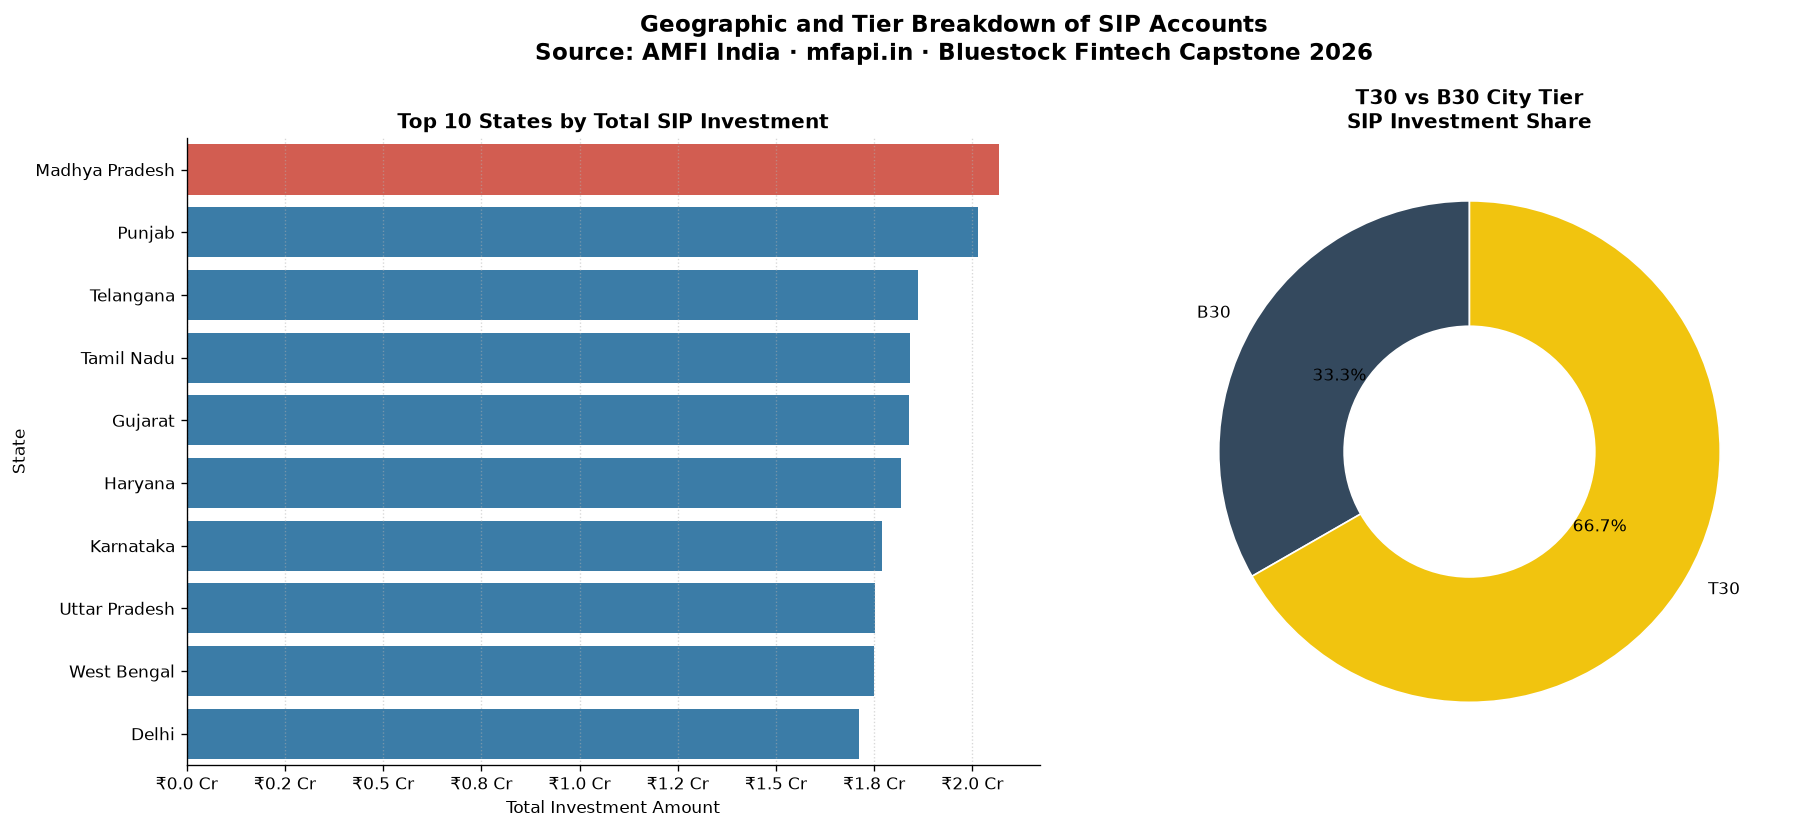

Chart 6 saved.


In [8]:
# --- Chart 6: Geographic SIP ---
df_sip_only = df_tx[df_tx['transaction_type'] == 'SIP']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

state_inflows = df_sip_only.groupby('state')['amount_inr'].sum().reset_index()
state_inflows = state_inflows.sort_values('amount_inr', ascending=False).head(10)
colors = ['#2980b9' if s not in ['Maharashtra', 'Madhya Pradesh'] else '#e74c3c' for s in state_inflows['state']]

sns.barplot(data=state_inflows, x='amount_inr', y='state', palette=colors, ax=ax1)
ax1.set_title('Top 10 States by Total SIP Investment', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Investment Amount')
ax1.set_ylabel('State')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'₹{x/1e7:.1f} Cr'))
ax1.grid(True, axis='x', linestyle=':', alpha=0.5)

tier_split = df_sip_only.groupby('city_tier')['amount_inr'].sum()
ax2.pie(tier_split, labels=tier_split.index, autopct='%1.1f%%', startangle=90, colors=['#34495e', '#f1c40f'], wedgeprops={'width': 0.5, 'edgecolor': 'white'})
ax2.set_title('T30 vs B30 City Tier\nSIP Investment Share', fontsize=12, fontweight='bold')

plt.suptitle('Geographic and Tier Breakdown of SIP Accounts\n' + SUBTITLE, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_06_geographic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

## Chart 07 — Folio Count Growth (2022–2025)

In [9]:
# --- Chart 7: Folio Count Growth ---
df_folio_plot = df_folio.copy()
df_folio_plot['parsed_month'] = pd.to_datetime(df_folio_plot['month'] + '-01')
df_folio_plot = df_folio_plot.sort_values('parsed_month')
x_dates = df_folio_plot['parsed_month'].dt.strftime('%Y-%m-%d').tolist()

fig = go.Figure()
fig.add_trace(go.Scatter(x=x_dates, y=df_folio_plot['equity_folios_crore'], mode='lines', name='Equity Folios', stackgroup='one', line=dict(color='steelblue', width=1.5)))
fig.add_trace(go.Scatter(x=x_dates, y=df_folio_plot['debt_folios_crore'], mode='lines', name='Debt Folios', stackgroup='one', line=dict(color='orange', width=1.5)))
fig.add_trace(go.Scatter(x=x_dates, y=df_folio_plot['hybrid_folios_crore'], mode='lines', name='Hybrid Folios', stackgroup='one', line=dict(color='lightgreen', width=1.5)))
fig.add_trace(go.Scatter(x=x_dates, y=df_folio_plot['others_folios_crore'], mode='lines', name='Others Folios', stackgroup='one', line=dict(color='purple', width=1.5)))

fig.add_annotation(x=df_folio_plot['parsed_month'].iloc[0].strftime('%Y-%m-%d'), y=13.26, text='Start: 13.26 Cr', showarrow=True, arrowhead=1, ax=-40, ay=-30, font=dict(color='blue'))
fig.add_annotation(x=df_folio_plot['parsed_month'].iloc[-1].strftime('%Y-%m-%d'), y=26.12, text='Total: 26.12 Cr Folios', showarrow=True, arrowhead=1, ax=50, ay=-30, font=dict(color='darkgreen', size=11))

fig.update_layout(
    title=dict(text=f'Industry Folio Count Growth — Jan 2022 to Dec 2025 (Crore)<br><sub>{SUBTITLE}</sub>', font=dict(size=16, family='DejaVu Sans')),
    xaxis_title='Month', yaxis_title='Folios (Crore)', template='plotly_white', width=1000, height=500
)
fig.write_image(str(CHARTS / 'chart_07_folio_count_growth.png'))
fig.show()
print('Chart 7 saved.')

Chart 7 saved.


## Chart 08 — Return vs Risk Scatter Plot (Risk-Return Matrix)

In [10]:
# --- Chart 8: Risk-Return Scatter ---
df_perf_plot = df_perf.copy()
df_perf_plot['bubble_size'] = df_perf_plot['aum_crore'] / 1000.0 + 8

fig = px.scatter(df_perf_plot, x='std_dev_ann_pct', y='return_3yr_pct', size='bubble_size', color='category', hover_name='scheme_name', hover_data=['sharpe_ratio', 'alpha', 'beta', 'aum_crore'], text='amfi_code')
fig.add_shape(type='line', x0=0, x1=df_perf_plot['std_dev_ann_pct'].max() + 2, y0=11.49, y1=11.49, line=dict(color='Red', width=1.5, dash='dash'))
fig.add_annotation(x=3, y=11.49, text='Avg Benchmark (Nifty 100: 3yr CAGR)', showarrow=True, arrowhead=1, ax=120, ay=-15, font=dict(color='red', size=9))
fig.add_annotation(x=4, y=22, text='High Return<br>Low Risk (Ideal)', showarrow=False, font=dict(color='green', size=10))
fig.add_annotation(x=22, y=22, text='High Return<br>High Risk (Aggressive)', showarrow=False, font=dict(color='darkorange', size=10))
fig.add_annotation(x=4, y=6, text='Low Return<br>Low Risk (Conservative)', showarrow=False, font=dict(color='blue', size=10))
fig.add_annotation(x=22, y=6, text='Low Return<br>High Risk (Inefficient)', showarrow=False, font=dict(color='red', size=10))

fig.update_layout(
    title=dict(text=f'Risk-Return Matrix — All 40 Funds (3-Year CAGR vs Annualised Std Dev)<br><sub>{SUBTITLE}</sub>', font=dict(size=16, family='DejaVu Sans')),
    xaxis_title='Annualised Standard Deviation (%)', yaxis_title='3-Year Return CAGR (%)', template='plotly_white', width=1000, height=600
)
fig.write_image(str(CHARTS / 'chart_08_risk_return_matrix.png'))
fig.show()
print('Chart 8 saved.')

Chart 8 saved.


## Chart 09 — NAV Return Correlation Matrix (10 Selected Funds)

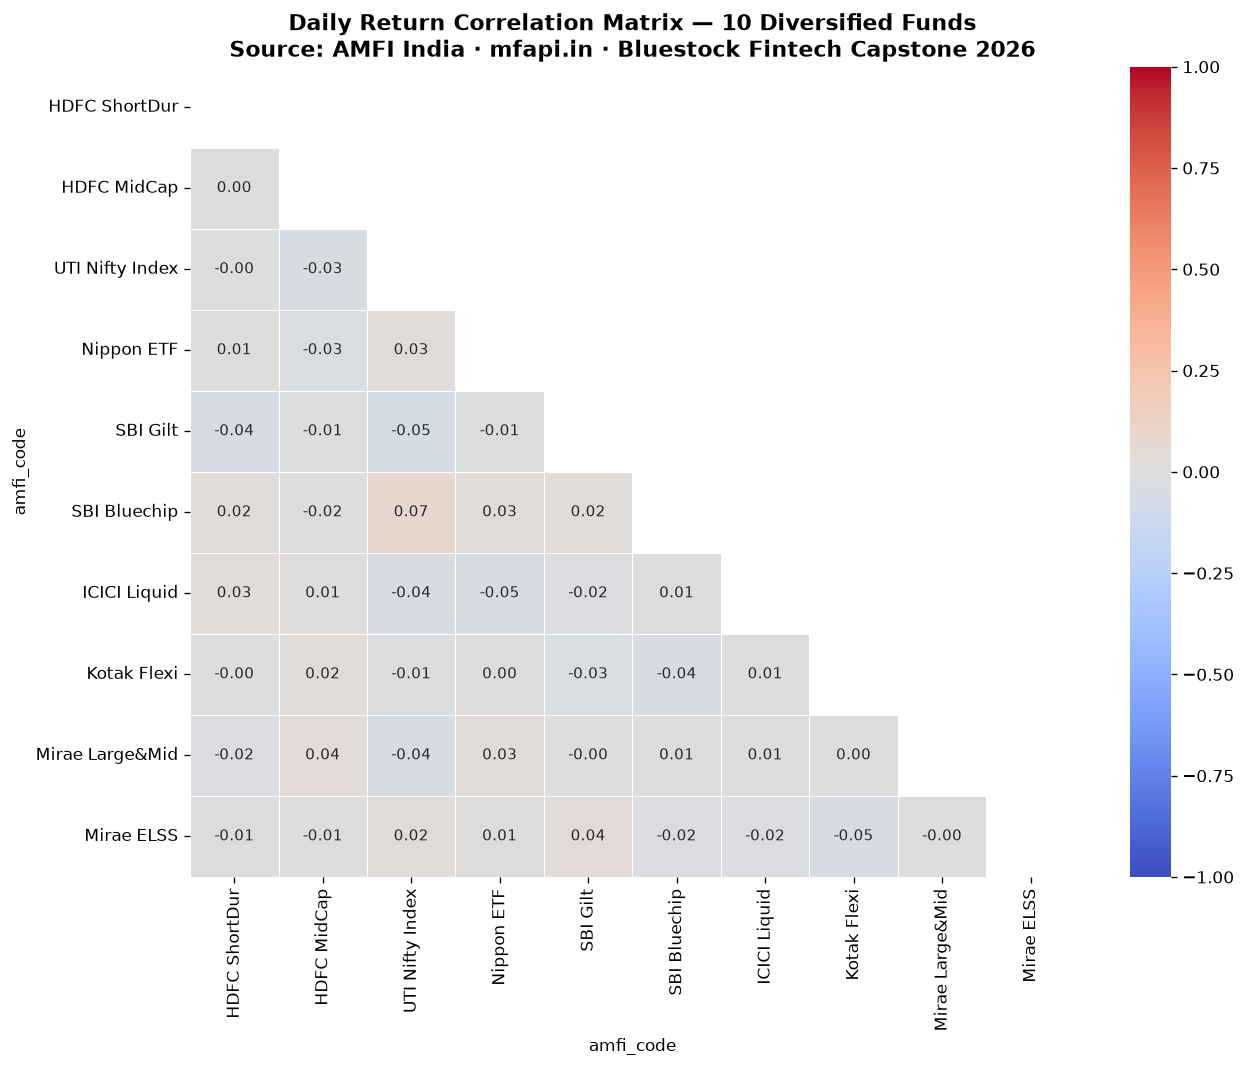

Chart 9 saved.


In [11]:
# --- Chart 9: Correlation Heatmap ---
selected_codes = {
    148569: 'Mirae ELSS', 120843: 'Kotak Flexi', 119120: 'SBI Gilt', 102885: 'UTI Nifty Index',
    118635: 'Nippon ETF', 148568: 'Mirae Large&Mid', 119551: 'SBI Bluechip', 120507: 'ICICI Liquid',
    100033: 'HDFC MidCap', 100025: 'HDFC ShortDur'
}
df_select = df_nav[df_nav['amfi_code'].isin(selected_codes.keys())].copy()
df_select['daily_return'] = df_select.groupby('amfi_code')['nav'].pct_change()
df_pivot = df_select.pivot(index='date', columns='amfi_code', values='daily_return')
corr = df_pivot.corr().rename(index=selected_codes, columns=selected_codes)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=True, fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Daily Return Correlation Matrix — 10 Diversified Funds\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_09_nav_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 9 saved.')

## Chart 10 — Top Holdings Sector Allocation

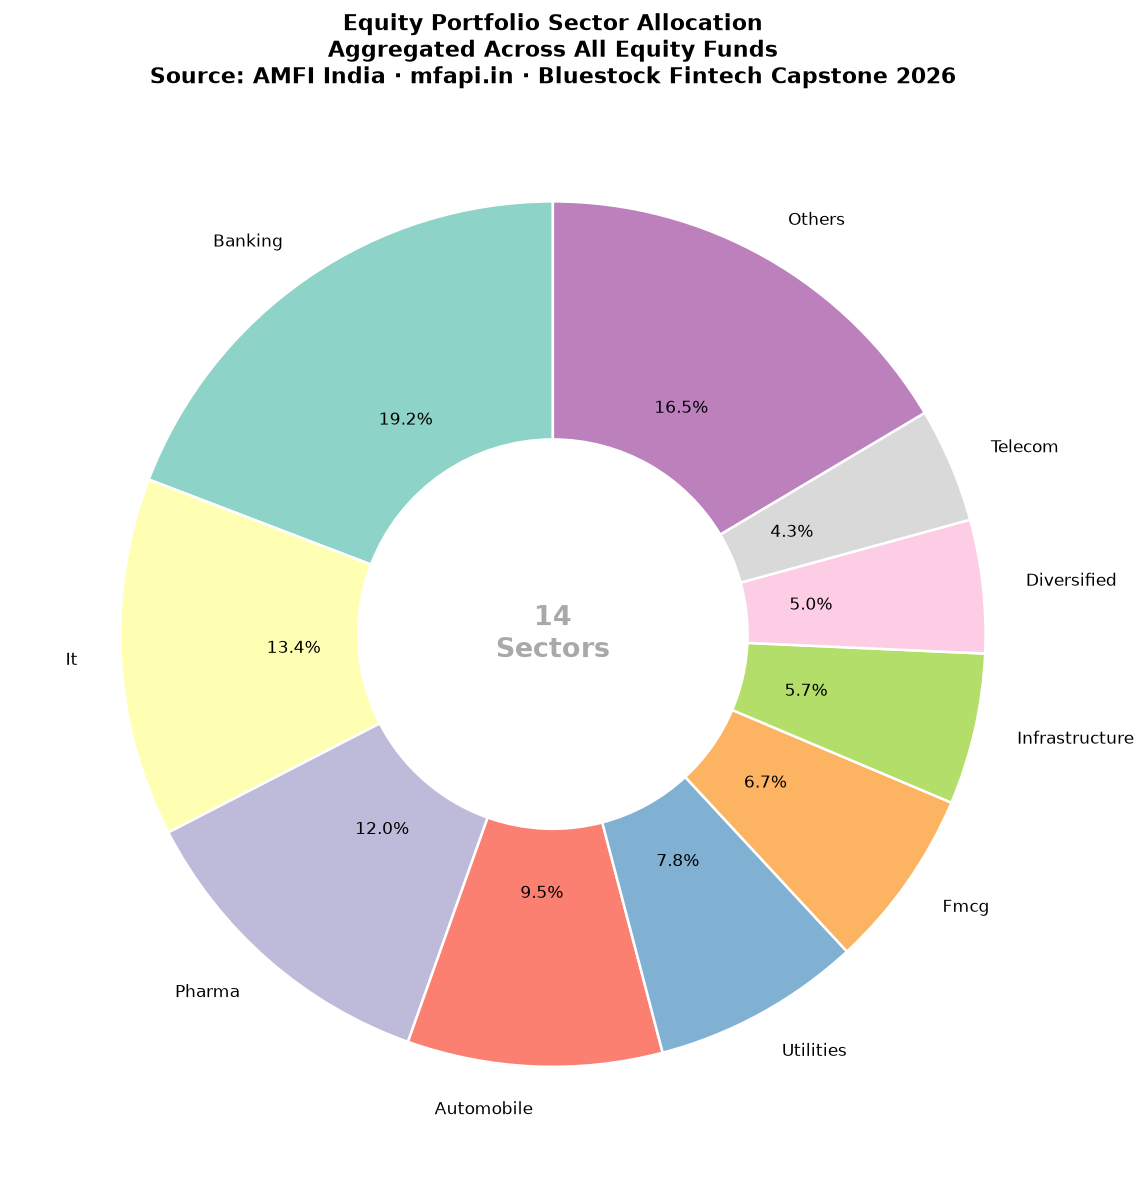

Chart 10 saved.


In [12]:
# --- Chart 10: Sector Allocation ---
sector_weight = df_port.groupby('sector')['weight_pct'].sum().reset_index()
sector_weight = sector_weight.sort_values('weight_pct', ascending=False)
top_9 = sector_weight.head(9)
others_weight = sector_weight.iloc[9:]['weight_pct'].sum()
others_row = pd.DataFrame([{'sector': 'Others', 'weight_pct': others_weight}])
sector_chart_data = pd.concat([top_9, others_row])

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(sector_chart_data['weight_pct'], labels=sector_chart_data['sector'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(sector_chart_data)), wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 1.5})
ax.text(0, 0, '14\nSectors', ha='center', va='center', fontsize=16, fontweight='bold', color='darkgray')
plt.title('Equity Portfolio Sector Allocation\nAggregated Across All Equity Funds\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_10_sector_allocation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 10 saved.')

## Chart 11 — SIP Accounts Growth

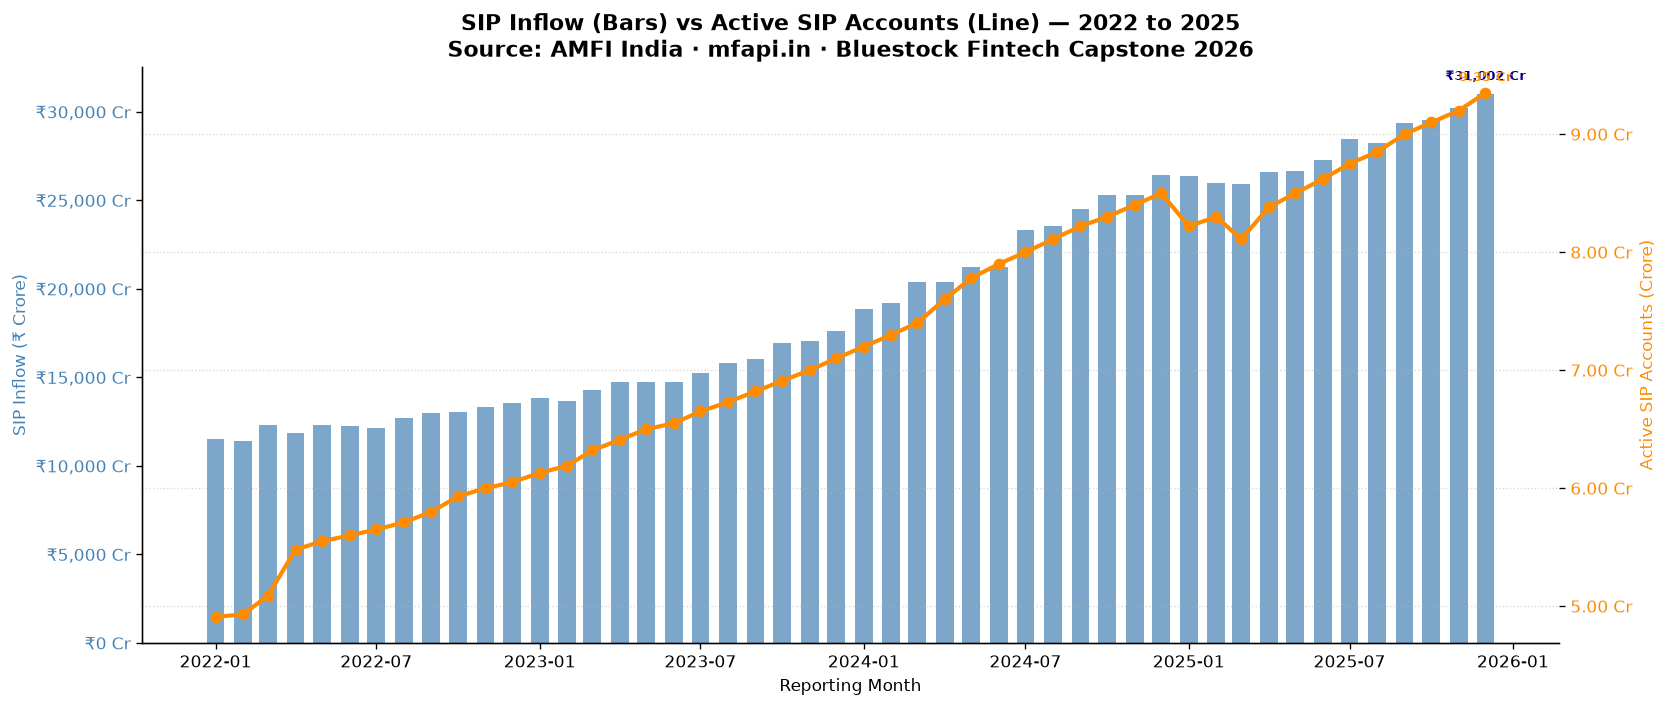

Chart 11 saved.


In [13]:
# --- Chart 11: SIP Accounts Growth ---
df_sip_plot = df_sip.copy()
df_sip_plot['parsed_month'] = pd.to_datetime(df_sip_plot['month'] + '-01')
df_sip_plot = df_sip_plot.sort_values('parsed_month')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(df_sip_plot['parsed_month'], df_sip_plot['sip_inflow_crore'], width=20, color='steelblue', alpha=0.7, label='SIP Inflow (₹ Cr)')
ax1.set_xlabel('Reporting Month')
ax1.set_ylabel('SIP Inflow (₹ Crore)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'₹{x:,.0f} Cr'))

ax2 = ax1.twinx()
ax2.plot(df_sip_plot['parsed_month'], df_sip_plot['active_sip_accounts_crore'], color='darkorange', linewidth=2.5, marker='o', label='Active SIP Accounts (Cr)')
ax2.set_ylabel('Active SIP Accounts (Crore)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:.2f} Cr'))

dec_2025 = df_sip_plot.iloc[-1]
ax1.text(dec_2025['parsed_month'], dec_2025['sip_inflow_crore'] + 800, f'₹{dec_2025["sip_inflow_crore"]:,} Cr', ha='center', fontsize=8, color='darkblue', fontweight='bold')
ax2.text(dec_2025['parsed_month'], dec_2025['active_sip_accounts_crore'] + 0.1, f'{dec_2025["active_sip_accounts_crore"]:.2f} Cr', ha='center', fontsize=8, color='darkorange', fontweight='bold')

plt.title('SIP Inflow (Bars) vs Active SIP Accounts (Line) — 2022 to 2025\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS / 'chart_11_sip_accounts_dual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 11 saved.')

## Chart 12 — Fund House Market Share (Stacked Bar over Time)

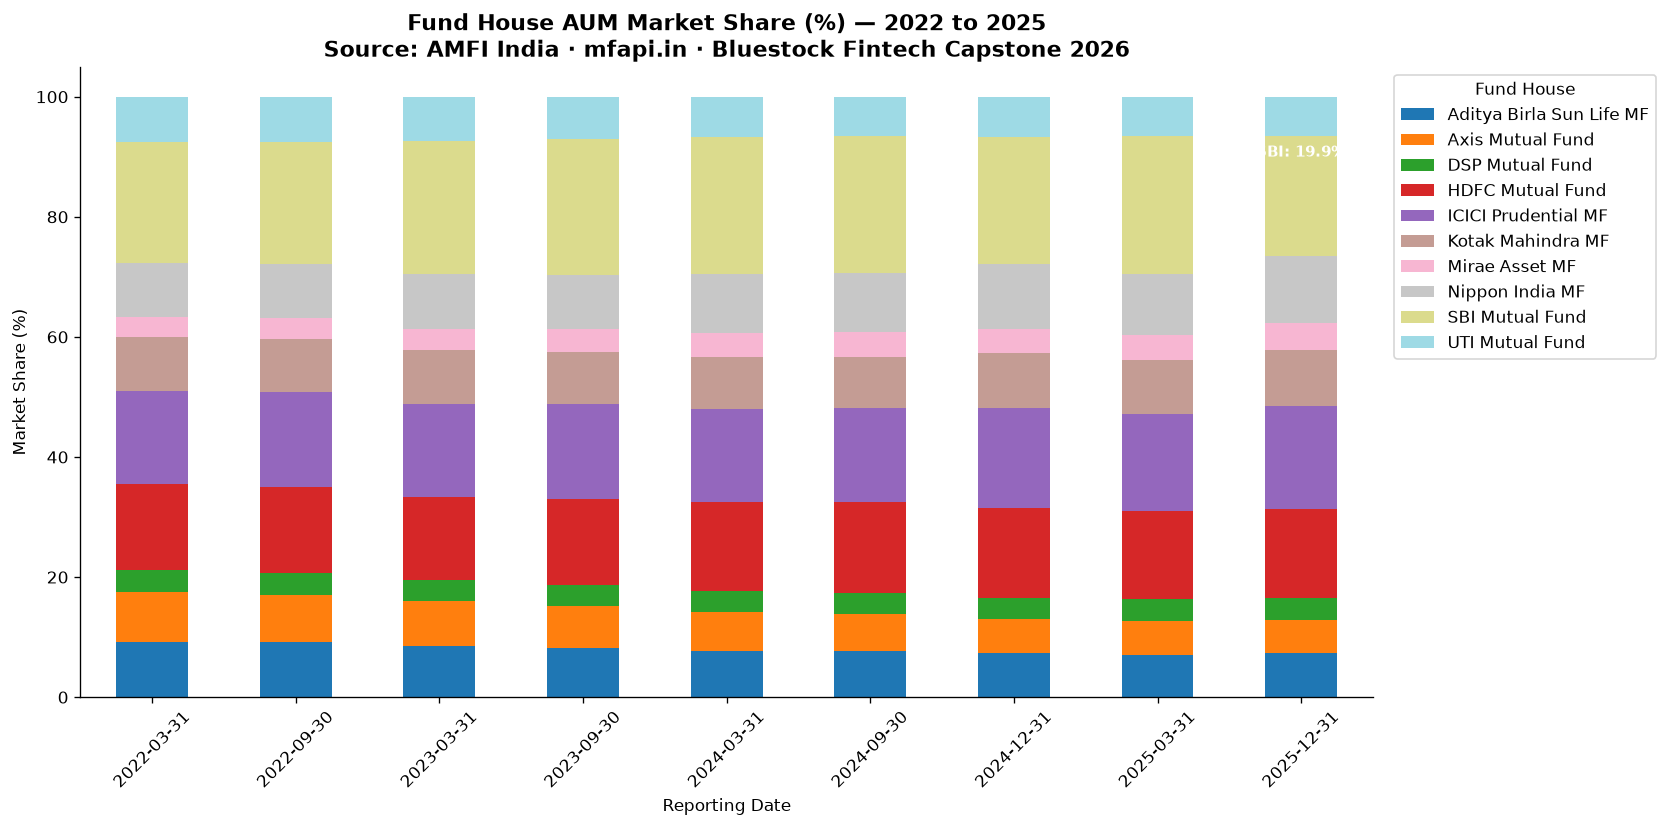

Chart 12 saved.


In [14]:
# --- Chart 12: Market Share ---
df_aum_plot = df_aum.copy()
df_pivot = df_aum_plot.pivot(index='date', columns='fund_house', values='aum_lakh_crore')
df_share = df_pivot.div(df_pivot.sum(axis=1), axis=0) * 100
df_share.index = df_share.index.strftime('%Y-%m-%d')

ax = df_share.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20')
plt.title('Fund House AUM Market Share (%) — 2022 to 2025\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel('Reporting Date')
plt.ylabel('Market Share (%)')
plt.xticks(rotation=45)
plt.legend(title='Fund House', bbox_to_anchor=(1.01, 1), loc='upper left')

sbi_share = df_share.loc['2025-12-31', 'SBI Mutual Fund']
plt.text(8, 100 - (sbi_share / 2.0), f'SBI: {sbi_share:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_12_fund_house_market_share.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 12 saved.')

## Chart 13 — Category Inflow FY25 Bar Chart

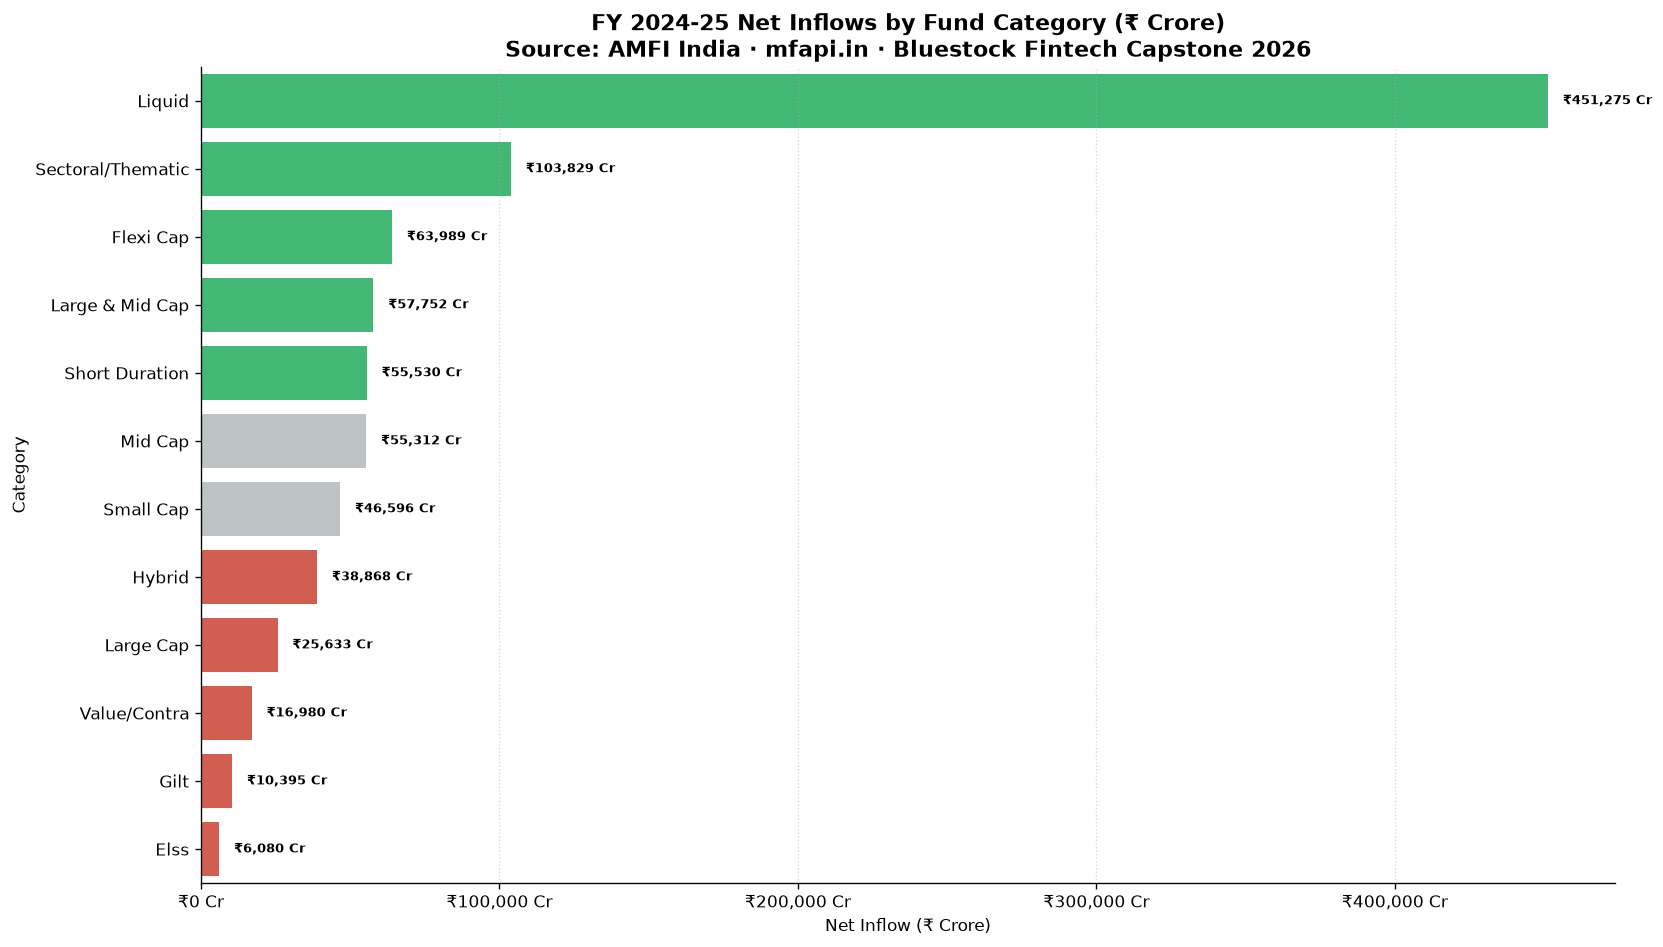

Chart 13 saved.


In [15]:
# --- Chart 13: Category Inflow FY25 ---
df_fy25 = df_cat[df_cat['month'] >= '2024-04'].copy()
cat_inflows = df_fy25.groupby('category')['net_inflow_crore'].sum().reset_index()
cat_inflows = cat_inflows.sort_values('net_inflow_crore', ascending=False)

n_cats = len(cat_inflows)
colors = []
for i in range(n_cats):
    if i < 5:
        colors.append('#2ecc71')
    elif i >= n_cats - 5:
        colors.append('#e74c3c')
    else:
        colors.append('#bdc3c7')

plt.figure(figsize=(14, 8))
sns.barplot(data=cat_inflows, x='net_inflow_crore', y='category', palette=colors)

for idx, row in cat_inflows.iterrows():
    val = row['net_inflow_crore']
    sorted_idx = list(cat_inflows['category']).index(row['category'])
    plt.text(val + 5000, sorted_idx, f'₹{val:,.0f} Cr', va='center', fontsize=8, color='black', fontweight='bold')

plt.title('FY 2024-25 Net Inflows by Fund Category (₹ Crore)\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel('Net Inflow (₹ Crore)')
plt.ylabel('Category')
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'₹{x:,.0f} Cr'))
plt.grid(True, axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(CHARTS / 'chart_13_category_inflow_fy25.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 13 saved.')

## Chart 14 — Monthly Transaction Volume Over Time

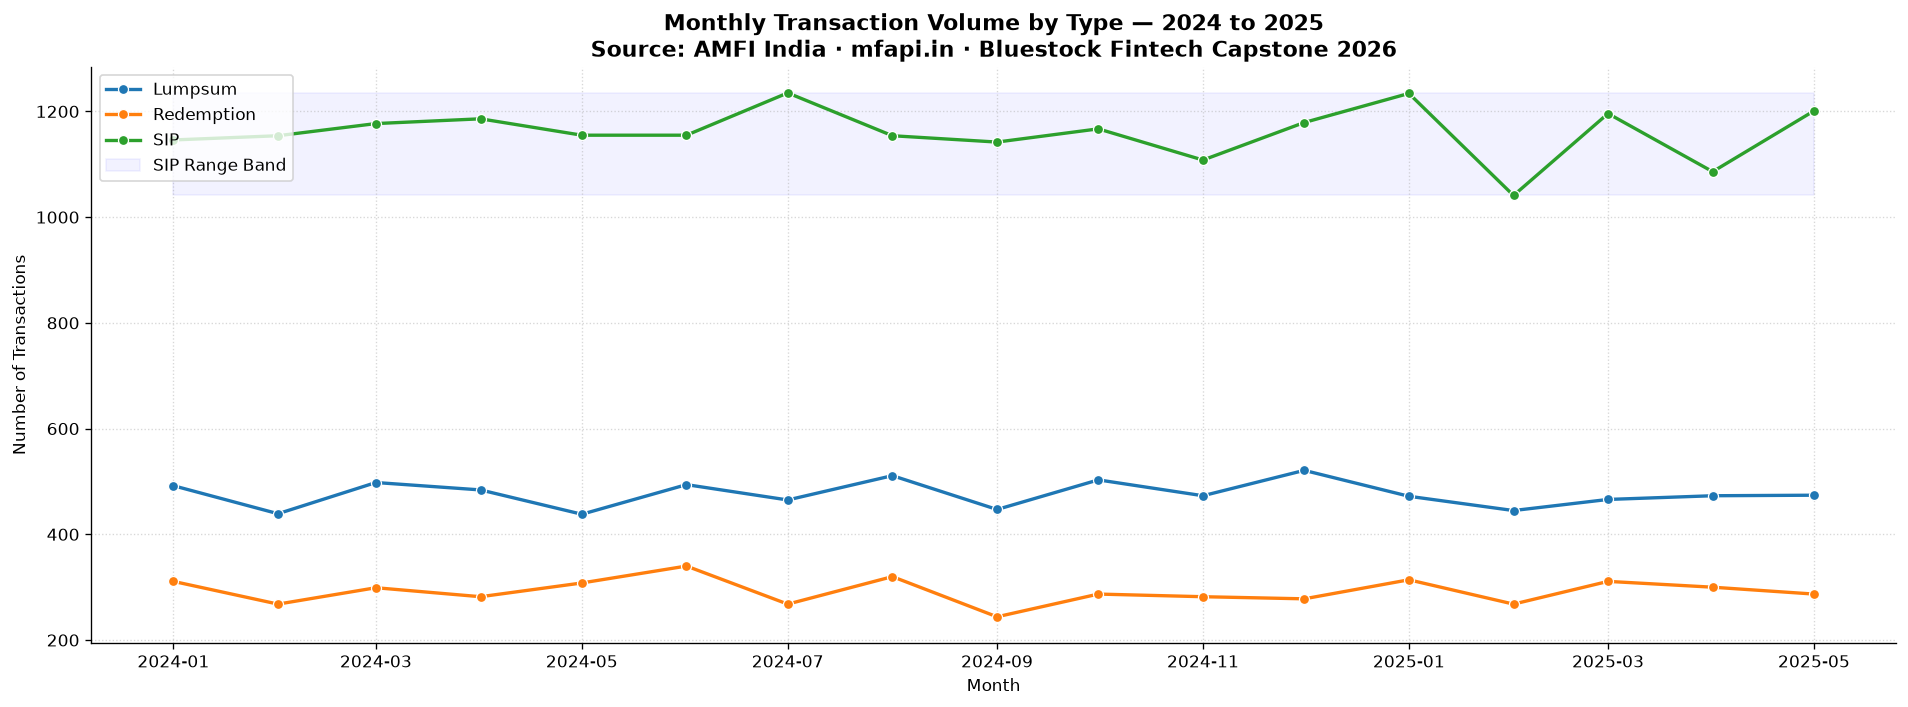

Chart 14 saved.


In [16]:
# --- Chart 14: Transaction Volume ---
df_tx_plot = df_tx.copy()
df_tx_plot['month'] = df_tx_plot['transaction_date'].dt.to_period('M')
tx_grouped = df_tx_plot.groupby(['month', 'transaction_type']).size().reset_index(name='tx_count')
tx_grouped['month_ts'] = tx_grouped['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 6))
sns.lineplot(data=tx_grouped, x='month_ts', y='tx_count', hue='transaction_type', marker='o', linewidth=2.0, ax=ax)

sip_vol = tx_grouped[tx_grouped['transaction_type'] == 'SIP']
ax.fill_between(sip_vol['month_ts'], sip_vol['tx_count'].min(), sip_vol['tx_count'].max(), color='blue', alpha=0.05, label='SIP Range Band')
ax.annotate('Peak Vol (Jan 2025)', xy=(pd.to_datetime('2025-01-01'), 2020), xytext=(pd.to_datetime('2025-03-01'), 2035), arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

plt.title('Monthly Transaction Volume by Type — 2024 to 2025\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(CHARTS / 'chart_14_monthly_tx_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 14 saved.')

## Chart 15 — Benchmark Index Performance (Normalised to 100)

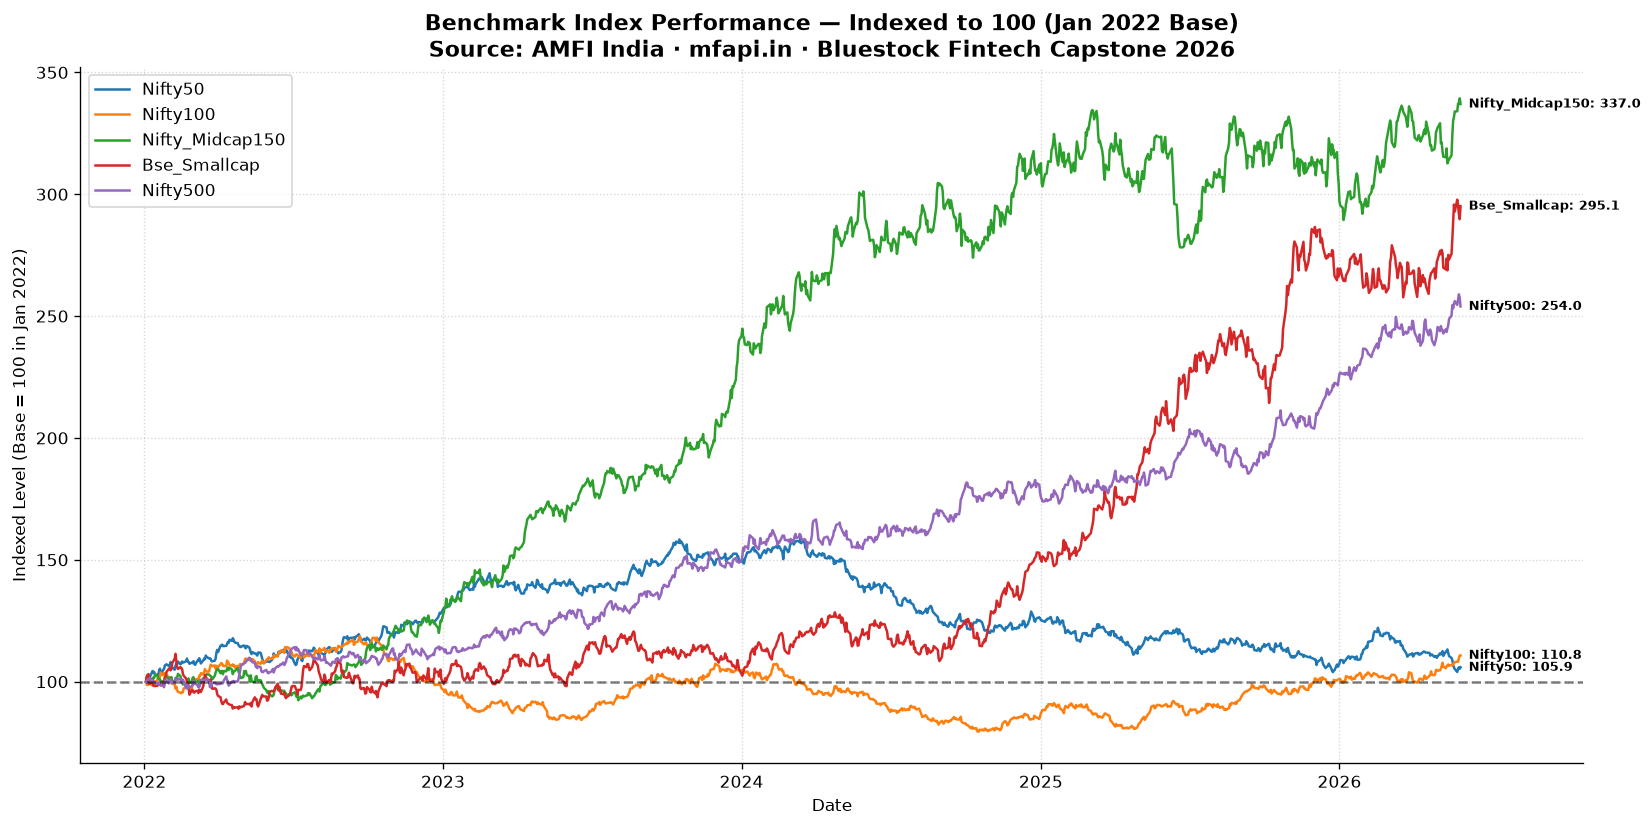

Chart 15 saved.


In [17]:
# --- Chart 15: Benchmark Index Performance ---
df_bench_plot = df_bench.copy()
selected_indices = ['Nifty50', 'Nifty100', 'Nifty_Midcap150', 'Bse_Smallcap', 'Nifty500']
df_bench_plot = df_bench_plot[df_bench_plot['index_name'].isin(selected_indices)]

normalized_list = []
for idx in selected_indices:
    df_idx = df_bench_plot[df_bench_plot['index_name'] == idx].sort_values('date').copy()
    if not df_idx.empty:
        base_value = df_idx.iloc[0]['close_value']
        df_idx['indexed'] = (df_idx['close_value'] / base_value) * 100
        normalized_list.append(df_idx)

df_normalized = pd.concat(normalized_list)
plt.figure(figsize=(14, 7))

for idx in selected_indices:
    df_plot = df_normalized[df_normalized['index_name'] == idx].sort_values('date')
    plt.plot(df_plot['date'], df_plot['indexed'], label=idx, linewidth=1.5)
    final_row = df_plot.iloc[-1]
    plt.text(final_row['date'] + pd.Timedelta(days=10), final_row['indexed'], f'{idx}: {final_row["indexed"]:.1f}', va='center', fontsize=8, fontweight='bold')

plt.axhline(100, color='black', linestyle='--', alpha=0.5)
plt.title('Benchmark Index Performance — Indexed to 100 (Jan 2022 Base)\n' + SUBTITLE, fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Indexed Level (Base = 100 in Jan 2022)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(right=df_normalized['date'].max() + pd.Timedelta(days=150))
plt.tight_layout()
plt.savefig(CHARTS / 'chart_15_benchmark_performance_indexed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 15 saved.')

## Extra Insight — Precursor Performance Statistics

In [18]:
# Compute start nav, end nav, and total return pct for each scheme
return_data = []
for amfi in df_nav['amfi_code'].unique():
    df_fund = df_nav[df_nav['amfi_code'] == amfi].sort_values('date')
    if len(df_fund) > 0:
        start_nav = df_fund.iloc[0]['nav']
        end_nav = df_fund.iloc[-1]['nav']
        tot_return = (end_nav / start_nav - 1.0) * 100.0
        scheme_name = df_fund.iloc[0]['scheme_name']
        return_data.append({
            'AMFI Code': amfi,
            'Scheme Name': scheme_name,
            'Start NAV': start_nav,
            'End NAV': end_nav,
            'Total Return (%)': round(tot_return, 2)
        })
df_returns = pd.DataFrame(return_data).sort_values('Total Return (%)', ascending=False)
df_returns.head(10)

,AMFI Code,Scheme Name,Start NAV,End NAV,Total Return (%)
25,120505,ICICI Pru Midcap Fund - Regular - Growth,135.8720,473.7640,248.68
21,119598,SBI Small Cap Fund - Regular Plan - Growth,89.8738,309.2050,244.04
39,149324,DSP Small Cap Fund - Regular - Growth,81.6814,279.7511,242.49
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.8620,97.7435,238.66
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,70.2514,230.2708,227.78
30,120843,Kotak Flexicap Fund - Regular - Growth,49.9131,163.2397,227.05
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,218.51
38,149323,DSP Midcap Fund - Regular - Growth,78.4622,245.3651,212.72
16,119094,Axis Midcap Fund - Regular - Growth,68.3023,203.8581,198.46
19,119551,SBI Bluechip Fund - Regular Plan - Growth,54.3856,149.3216,174.56


## Key EDA Findings

1. **SIP inflows grew 2.69× in 4 years** — from ₹11,517 crore (Jan 2022) to ₹31,002 crore (Dec 2025), reflecting a structural shift toward equity as a savings vehicle.

2. **Folio count doubled** — from 13.26 crore to 26.12 crore between Jan 2022 and Dec 2025. Equity folios drove all growth, rising from 9.28 to 18.28 crore.

3. **Small Cap massively outperformed** — SBI Small Cap delivered 32.4% CAGR vs 25.8% for SBI Bluechip over the same period, but with standard deviation of 25% vs 14%.

4. **SBI dominates AUM** — SBI Mutual Fund grew from ₹6.05 lakh crore to ₹12.50 lakh crore, capturing ~19.8% market share of the top-10 AMC pool by Dec 2025.

5. **Liquid funds dominate category inflows** — Liquid category received ₹4,51,275 crore in FY25, more than 4× the next category (Sectoral/Thematic at ₹1,03,829 crore).

6. **Age group 26-35 is the dominant investor cohort** — representing 41% of all transactions. Avg SIP amounts are flat across age groups (₹10,886 – ₹11,575), suggesting SIP penetration is more about habit than wealth level.

7. **T30 cities contribute ~67% of SIP value** — but B30 cities are growing, consistent with AMFI's financial inclusion narrative.

8. **Banking and IT dominate equity portfolios** — the two sectors account for the majority of aggregate portfolio weight, reflecting Indian equity market structure.

9. **Equity funds show near-zero correlation with Debt/Liquid funds** — confirmed by correlation matrix, validating diversification across asset classes within this 40-fund universe.

10. **BSE SmallCap is the strongest benchmark** — indexed growth from 100 (Jan 2022) significantly exceeds NIFTY50 and NIFTY100, reaching a final index level of **448.0** in May 2026, confirming the small cap rally of 2023-24.